<a href="https://www.kaggle.com/code/riteshkumarweb/decisiontree-visualization-with-dtreeviz?scriptVersionId=317769345" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [136]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/riteshkumarweb/salary-prediction/Salary.csv
/kaggle/input/datasets/organizations/uciml/iris/Iris.csv
/kaggle/input/datasets/organizations/uciml/iris/database.sqlite


In [ ]:
# 🌳 dtreeviz

# dtreeviz is a visualization library used to create
# beautiful and detailed visualizations for Decision Trees

# It helps understand:
# ✅ Tree structure
# ✅ Feature splits
# ✅ Gini / Entropy
# ✅ Decision boundaries
# ✅ Prediction paths
# ✅ Leaf node predictions


# 📦 model()

# model() creates the dtreeviz visualization object

# Important Parameters:

# modelname like model1 = DecisionTreeClassifier(max_depth = 5 )
# → Trained Decision Tree model

# X_train
# → Training feature dataset

# y_train
# → Training target labels

# feature_names
# → Names of input features

# target_name
# → Name of target/output column

# class_names
# → Names of classes
# Used mainly in classification


# 👁️ view()

# view() displays the visualization

# Important Parameters:

# scale
# → Controls visualization size

# orientation
# → Tree direction
# 'LR' → Left to Right
# 'TD' → Top Down

# fancy
# → Creates colorful visualization

# show_node_labels
# → Shows node IDs

# show_just_path
# → Shows only prediction path for a sample

# X
# → Specific sample for prediction path visualization

# depth_range_to_display
# → Displays selected tree depth levels only

# 💾 save()
# save() saves visualization file

# Example formats:
# .svg
# .pdf

# ⚠️ Important:

# scale belongs to view()
# NOT model()

# ❌ Wrong:
# model(scale=2)

# ✅ Correct:
# viz_model.view(scale=2)

In [137]:
!pip install dtreeviz

In [138]:
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/iris/Iris.csv')

In [139]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [140]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

In [141]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2


In [142]:
df.sample(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
32,33,5.2,4.1,1.5,0.1,0
41,42,4.5,2.3,1.3,0.3,0
77,78,6.7,3.0,5.0,1.7,1
147,148,6.5,3.0,5.2,2.0,2
53,54,5.5,2.3,4.0,1.3,1
67,68,5.8,2.7,4.1,1.0,1
91,92,6.1,3.0,4.6,1.4,1
31,32,5.4,3.4,1.5,0.4,0
50,51,7.0,3.2,4.7,1.4,1
20,21,5.4,3.4,1.7,0.2,0


In [143]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [144]:
df.drop(columns=['Id'],inplace = True)#Beacuse ID in not useful for for training 

In [145]:
df['Species'].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

In [146]:
X = df.iloc[:,0:4]
X

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [147]:
y = df.iloc[:,-1]
y 

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: Species, Length: 150, dtype: int64

In [148]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [149]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2
...,...,...,...,...
71,6.1,2.8,4.0,1.3
106,4.9,2.5,4.5,1.7
14,5.8,4.0,1.2,0.2
92,5.8,2.6,4.0,1.2


In [150]:
model1 = DecisionTreeClassifier(max_depth=3)
model1.fit(X_train,y_train)
y_pred_C = model1.predict(X_test)
from sklearn.metrics import accuracy_score
score = accuracy_score(y_test,y_pred_C)
print(f'The accuracy_score of this is data is {score*100:.2f}%')

The accuracy_score of this is data is 100.00%


[Text(0.375, 0.875, 'x[3] <= 0.8\ngini = 0.667\nsamples = 120\nvalue = [40, 41, 39]'),
 Text(0.25, 0.625, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[2] <= 4.75\ngini = 0.5\nsamples = 80\nvalue = [0, 41, 39]'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'x[3] <= 1.65\ngini = 0.053\nsamples = 37\nvalue = [0, 36, 1]'),
 Text(0.125, 0.125, 'gini = 0.0\nsamples = 36\nvalue = [0, 36, 0]'),
 Text(0.375, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.75, 0.375, 'x[3] <= 1.75\ngini = 0.206\nsamples = 43\nvalue = [0, 5, 38]'),
 Text(0.625, 0.125, 'gini = 0.5\nsamples = 8\nvalue = [0, 4, 4]'),
 Text(0.875, 0.125, 'gini = 0.056\nsamples = 35\nvalue = [0, 1, 34]')]

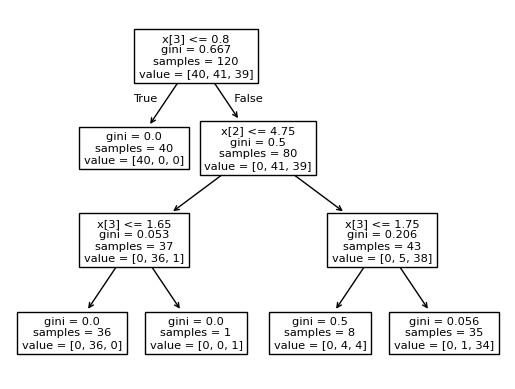

In [151]:
#The is the Outdated way to see tree and it wonot also look attractive 
from sklearn.tree import plot_tree
plot_tree(model1)

In [152]:
!pip install dtreeviz

In [153]:
import logging
logging.getLogger('matplotlib.font_manager').disabled = True

In [154]:
from dtreeviz import dtreeviz

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


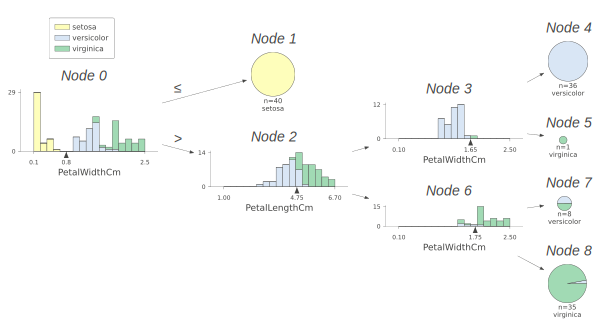

In [155]:
from dtreeviz import model

viz_model = model(
    model1,
    X_train,
    y_train,
    feature_names=X_train.columns,
    class_names=["setosa", "versicolor", "virginica"],
    
)
viz_model.view(orientation="LR",show_node_labels=True)

In [156]:
df2 = pd.read_csv('/kaggle/input/datasets/riteshkumarweb/salary-prediction/Salary.csv')

In [157]:
df2

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


In [158]:
X = df2[['YearsExperience']]
y = df2.iloc[:,1]
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train

model2 = DecisionTreeRegressor(max_depth=3)
model2.fit(X_train,y_train)
y_pred_R = model2.predict(X_test)
score = r2_score(y_test,y_pred_R)
print(f'The Accuracy of this Regreesion dataset it {score*100}% ')

The Accuracy of this Regreesion dataset it 92.2927480865252% 


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names


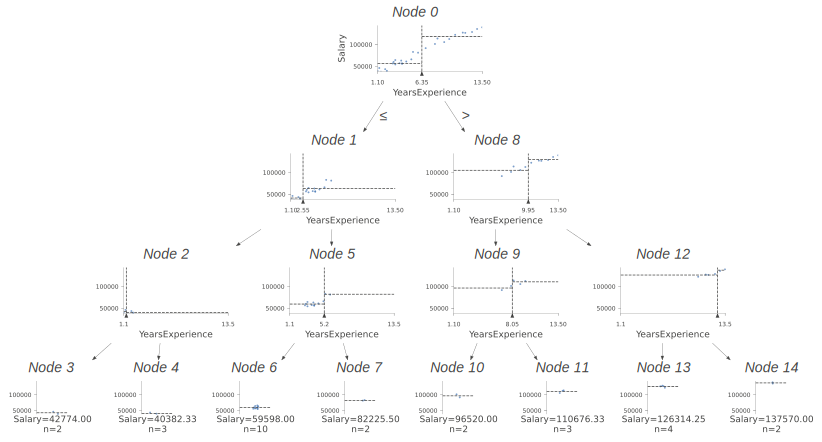

In [160]:
from dtreeviz import model

viz_model = model(
    model2,
    X_train,
    y_train,
    feature_names=X_train.columns,
    target_name= "Salary",
    
)
viz_model.view(orientation="TD",show_node_labels=True)